Loading data from: /Users/kanchan/Desktop/remittance inflow analysis using python/finaaal dataset.xlsx

Preprocessed Data Sample (Last 5 Years):
    Year    Remittance           GDP  Remittance_share_GDP
27  2020  8.107745e+09  3.343366e+10             24.250246
28  2021  8.225961e+09  3.692484e+10             22.277579
29  2022  9.411659e+09  4.118294e+10             22.853297
30  2023  1.076441e+10  4.104777e+10             26.224109
31  2024  1.125446e+10  4.291427e+10             26.225458
\ 1. ADF Stationarity Test (log_Remittance) 
ADF Test Statistic: -2.8646
p-value: 0.0496

 2. OLS Econometric Model 
                            OLS Regression Results                            
Dep. Variable:         log_Remittance   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     125.1
Date:                Sat, 03 Oct 2026   Prob (F-statistic):         

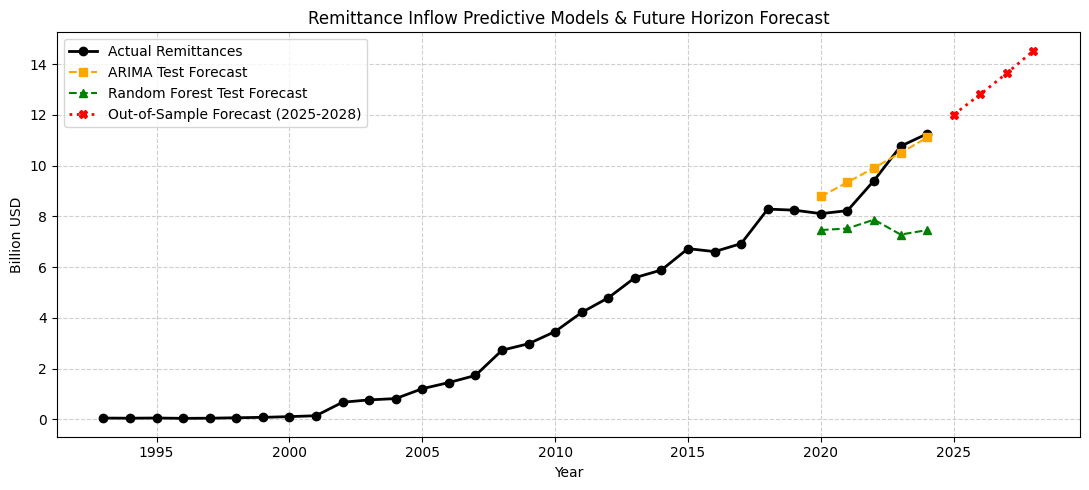


Pipeline completed successfully! All plots saved in: /Users/kanchan/Desktop/remittance inflow analysis using python/outputs


In [11]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')


# 1. SETUP & DATA LOADING

folder_path = '/Users/kanchan/Desktop/remittance inflow analysis using python'
file_name = 'finaaal dataset.xlsx'
file_path = os.path.join(folder_path, file_name)

output_dir = os.path.join(folder_path, 'outputs')
os.makedirs(output_dir, exist_ok=True)

print(f"Loading data from: {file_path}")
df = pd.read_excel(file_path, sheet_name='Sheet1')


# 2. DATA PREPROCESSING

# Exclude 2025 anomaly
df_clean = df[df['Year'] <= 2024].copy()
df_clean = df_clean.sort_values('Year').reset_index(drop=True)

# Calculate key ratios & log transformations
df_clean['Remittance_share_GDP'] = (
    df_clean['Remittance'] / df_clean['GDP']
) * 100

log_cols = ['Remittance', 'GDP', 'GFCF', 'Exchange_rate', 'labour force']
for col in log_cols:
    if col in df_clean.columns:
        df_clean[f'log_{col}'] = np.log(df_clean[col])

print('\nPreprocessed Data Sample (Last 5 Years):')
print(df_clean[['Year', 'Remittance', 'GDP', 'Remittance_share_GDP']].tail(5))


# 3. STATISTICAL DIAGNOSTICS & REGRESSION

print('\ 1. ADF Stationarity Test (log_Remittance) ')
adf_res = adfuller(df_clean['log_Remittance'].dropna())
print(f'ADF Test Statistic: {adf_res[0]:.4f}')
print(f'p-value: {adf_res[1]:.4f}')

print('\n 2. OLS Econometric Model ')
X = df_clean[['log_GDP', 'Exchange_rate', 'Inflation', 'Trade openness']]
X = sm.add_constant(X)
y = df_clean['log_Remittance']

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())


# 4. PREDICTIVE MODELING (TRAIN/TEST & FORECAST)
train = df_clean[df_clean['Year'] < 2020].copy()
test = df_clean[df_clean['Year'] >= 2020].copy()

train_y = train['Remittance'] / 1e9
test_y = test['Remittance'] / 1e9
full_y = df_clean['Remittance'] / 1e9

# ARIMA (1,1,1) Evaluation
arima_model = ARIMA(
    train_y,
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))

# Random Forest Evaluation
features = ['GDP', 'Exchange_rate', 'Inflation', 'Trade openness']
X_train = train[features].copy()
X_train['GDP'] = X_train['GDP'] / 1e9
X_test = test[features].copy()
X_test['GDP'] = X_test['GDP'] / 1e9

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, train_y)
rf_forecast = rf_model.predict(X_test)


# Metrics calculation
def get_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape


arima_mae, arima_rmse, arima_mape = get_metrics(test_y, arima_forecast)
rf_mae, rf_rmse, rf_mape = get_metrics(test_y, rf_forecast)

print('\n=== 3. Predictive Model Evaluation (2020-2024 Test Set) ===')
print(
    f'ARIMA(1,1,1) -> MAE: ${arima_mae:.3f}B | RMSE: ${arima_rmse:.3f}B | MAPE:'
    f' {arima_mape:.2f}%'
)
print(
    f'Random Forest -> MAE: ${rf_mae:.3f}B | RMSE: ${rf_rmse:.3f}B | MAPE:'
    f' {rf_mape:.2f}%'
)

# Out-of-sample Forecast (2025-2028)
final_arima = ARIMA(
    full_y,
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit()
future_years = np.array([2025, 2026, 2027, 2028])
future_forecast = final_arima.forecast(steps=4)

forecast_df = pd.DataFrame(
    {
        'Year': future_years,
        'Predicted_Remittance_Billion_USD': future_forecast.values,
    }
)
print('\n 4. Out-of-Sample Forecast (2025-2028) ')
print(forecast_df.to_string(index=False))


# 5. GENERATE ALL 5 VISUALIZATIONS
print('\nGenerating and saving all 5 figures')

# Figure 1: Remittance Inflows vs GDP Trend
plt.figure(figsize=(10, 5))
plt.plot(
    df_clean['Year'],
    df_clean['Remittance'] / 1e9,
    label='Remittance Inflows',
    marker='o',
    color='#1f77b4',
    linewidth=2,
)
plt.plot(
    df_clean['Year'],
    df_clean['GDP'] / 1e9,
    label='GDP',
    marker='s',
    color='#ff7f0e',
    linewidth=2,
)
plt.title('Macroeconomic Trend: Remittances vs GDP (1993 - 2024)', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Billion USD')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, '01_remittance_vs_gdp.png'), dpi=300
)
plt.close()

# Figure 2: Remittance Share as % of GDP
plt.figure(figsize=(10, 4.5))
plt.fill_between(
    df_clean['Year'],
    df_clean['Remittance_share_GDP'],
    color='teal',
    alpha=0.25,
)
plt.plot(
    df_clean['Year'],
    df_clean['Remittance_share_GDP'],
    color='teal',
    linewidth=2,
    marker='d',
)
plt.title('Remittance Inflows as % of GDP (1993 - 2024)', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Remittance Share (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, '02_remittance_share_gdp.png'), dpi=300
)
plt.close()

# Figure 3: Correlation Matrix
plt.figure(figsize=(8, 6))
corr_cols = [
    'log_Remittance',
    'log_GDP',
    'Exchange_rate',
    'Inflation',
    'Trade openness',
]
sns.heatmap(
    df_clean[corr_cols].corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f',
    square=True,
    cbar=True,
)
plt.title('Macroeconomic Predictor Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, '03_correlation_heatmap.png'), dpi=300
)
plt.close()

# Figure 4: OLS Model Residual Diagnostics
plt.figure(figsize=(8, 4.5))
plt.scatter(
    ols_model.fittedvalues,
    ols_model.resid,
    color='purple',
    alpha=0.7,
    edgecolors='k',
)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('OLS Residual Diagnostic Plot', fontsize=12)
plt.xlabel('Fitted Values (log_Remittance)')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '04_ols_residuals.png'), dpi=300)
plt.close()

# Figure 5: Model Forecast & Future Projections
plt.figure(figsize=(11, 5))
plt.plot(
    df_clean['Year'],
    full_y,
    label='Actual Remittances',
    marker='o',
    color='black',
    linewidth=2,
)
plt.plot(
    test['Year'],
    arima_forecast,
    label='ARIMA Test Forecast',
    linestyle='--',
    marker='s',
    color='orange',
)
plt.plot(
    test['Year'],
    rf_forecast,
    label='Random Forest Test Forecast',
    linestyle='--',
    marker='^',
    color='green',
)
plt.plot(
    future_years,
    future_forecast,
    label='Out-of-Sample Forecast (2025-2028)',
    linestyle=':',
    marker='X',
    color='red',
    linewidth=2,
)

plt.title(
    'Remittance Inflow Predictive Models & Future Horizon Forecast',
    fontsize=12,
)
plt.xlabel('Year')
plt.ylabel('Billion USD')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, '05_predictive_forecast.png'), dpi=300
)
plt.show()

print(f'\nPipeline completed successfully! All plots saved in: {output_dir}')